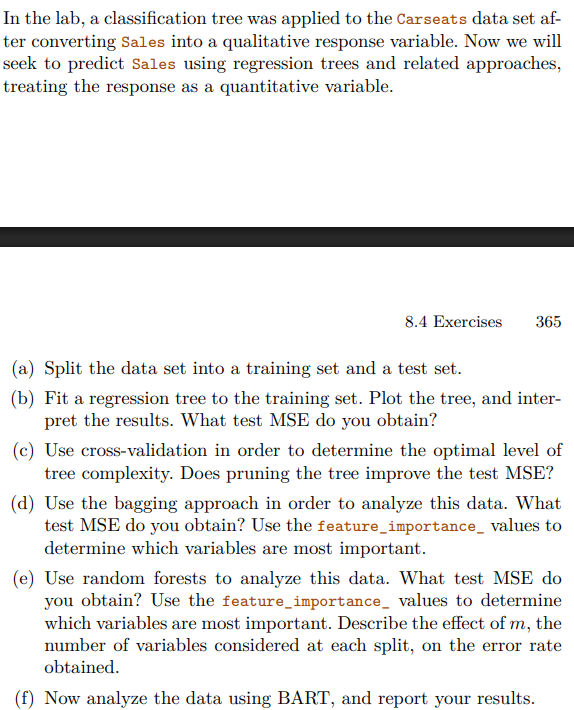

## (a) Split the data set into a training set and a test set.

In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline
import matplotlib.pyplot as plt

In [4]:
!pip install ISLP
from ISLP import load_data

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 41.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.3/349.3 kB 21.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 849.5/849.5 kB 41.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 42.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 8.0 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=2d02540c176cbccd9d51da26810c32ff71da489f7c37a8276bebd39fb94ed26b
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma


In [5]:
from sklearn.model_selection import train_test_split

Carseats = load_data('Carseats')
Carseats

,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US
0,9.50,138,73,11,276,120,Bad,42,17,Yes,Yes
1,11.22,111,48,16,260,83,Good,65,10,Yes,Yes
2,10.06,113,35,10,269,80,Medium,59,12,Yes,Yes
3,7.40,117,100,4,466,97,Medium,55,14,Yes,Yes
4,4.15,141,64,3,340,128,Bad,38,13,Yes,No
...,...,...,...,...,...,...,...,...,...,...,...
395,12.57,138,108,17,203,128,Good,33,14,Yes,Yes
396,6.14,139,23,3,37,120,Medium,55,11,No,Yes
397,7.41,162,26,12,368,159,Medium,40,18,Yes,Yes
398,5.94,100,79,7,284,95,Bad,50,12,Yes,Yes


In [6]:
Carseats['ShelveLoc'] = Carseats['ShelveLoc'].map({'Bad': -1, 'Good': 1, 'Medium': 0})
Carseats['Urban'] = Carseats['Urban'].map({'No': 0, 'Yes': 1})
Carseats['US'] = Carseats['US'].map({'No': 0, 'Yes': 1})
Carseats

,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US
0,9.50,138,73,11,276,120,-1,42,17,1,1
1,11.22,111,48,16,260,83,1,65,10,1,1
2,10.06,113,35,10,269,80,0,59,12,1,1
3,7.40,117,100,4,466,97,0,55,14,1,1
4,4.15,141,64,3,340,128,-1,38,13,1,0
...,...,...,...,...,...,...,...,...,...,...,...
395,12.57,138,108,17,203,128,1,33,14,1,1
396,6.14,139,23,3,37,120,0,55,11,0,1
397,7.41,162,26,12,368,159,0,40,18,1,1
398,5.94,100,79,7,284,95,-1,50,12,1,1


In [7]:
train_df, test_df = train_test_split(Carseats, test_size=0.5, random_state=42)

## (b) Fit a regression tree to the training set. Plot the tree, and interpret the results. What test MSE do you obtain?

In [8]:
from sklearn.tree import DecisionTreeRegressor
from sklearn import tree
import matplotlib.pyplot as plt

X_train = train_df.drop(columns=["Sales"])
y_train = train_df["Sales"]

X_test  = test_df.drop(columns=["Sales"])
y_test  = test_df["Sales"]
reg_tree = DecisionTreeRegressor(random_state=1, max_depth=4)
reg_tree.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=4, random_state=1)

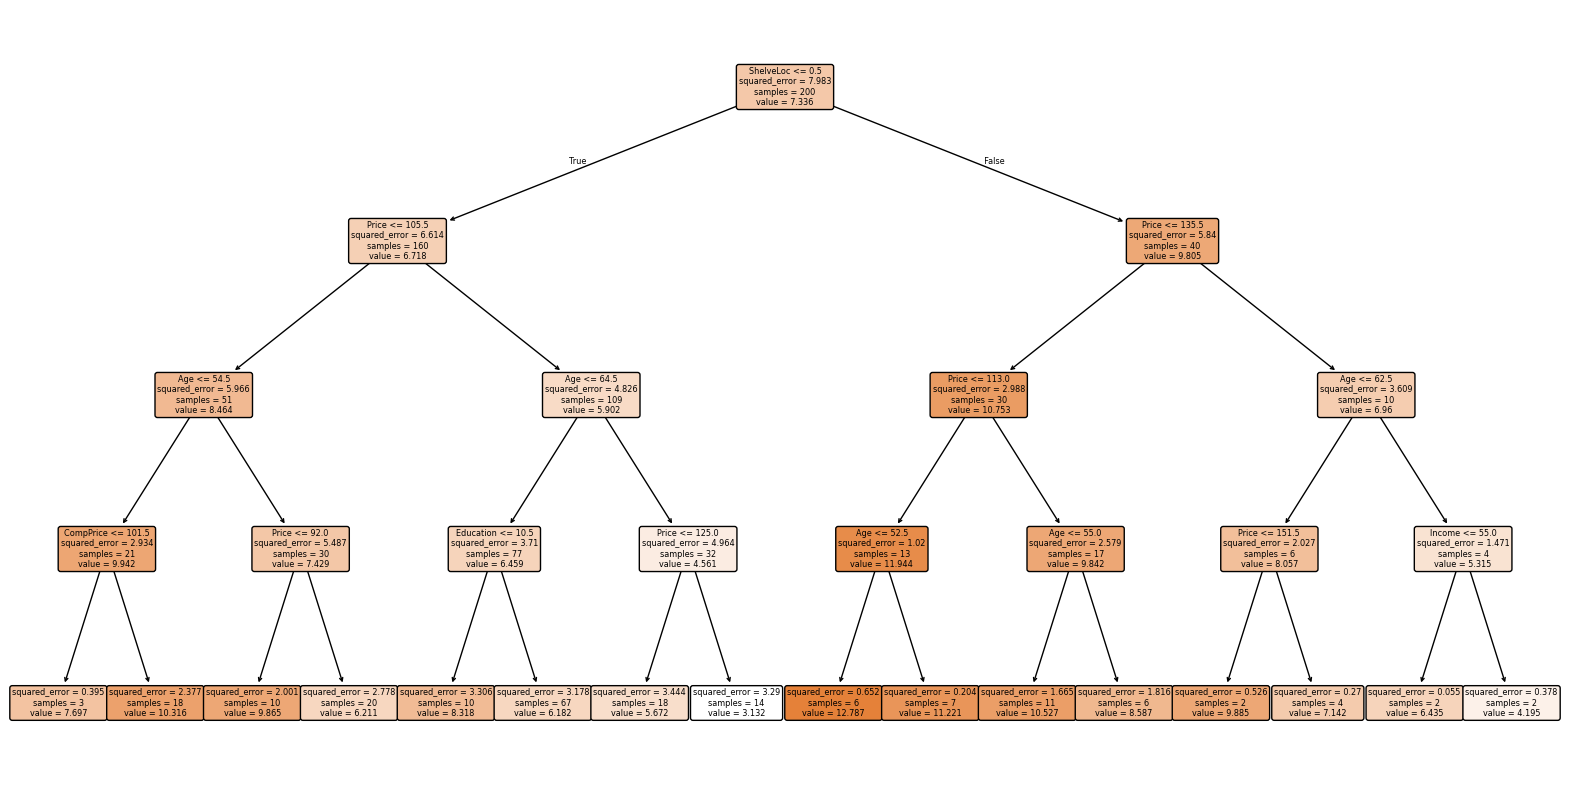

In [9]:
plt.figure(figsize=(20,10))
tree.plot_tree(reg_tree,
               feature_names=X_train.columns,
               filled=True,
               rounded=True)
plt.show()

In [10]:
from sklearn.metrics import mean_squared_error

y_pred = reg_tree.predict(X_test)
test_mse = mean_squared_error(y_test, y_pred)
test_mse

5.693949451031239

## (c) Use cross-validation in order to determine the optimal level of tree complexity. Does pruning the tree improve the test MSE?

In [11]:
path = reg_tree.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas
from sklearn.model_selection import cross_val_score
import numpy as np

cv_scores = []

for alpha in ccp_alphas:
    tree_cv = DecisionTreeRegressor(random_state=1, ccp_alpha=alpha)
    scores = -cross_val_score(
        tree_cv, X_train, y_train,
        scoring='neg_mean_squared_error',
        cv=10
    )
    cv_scores.append(scores.mean())

best_alpha = ccp_alphas[np.argmin(cv_scores)]
best_alpha

np.float64(0.2539365089285811)

In [13]:
pruned_tree = DecisionTreeRegressor(random_state=1, ccp_alpha=best_alpha)
pruned_tree.fit(X_train, y_train)

DecisionTreeRegressor(ccp_alpha=np.float64(0.2539365089285811), random_state=1)

In [14]:
from sklearn.metrics import mean_squared_error

y_pred_full = reg_tree.predict(X_test)
mse_full = mean_squared_error(y_test, y_pred_full)
mse_full

5.693949451031239

In [15]:
y_pred_pruned = pruned_tree.predict(X_test)
mse_pruned = mean_squared_error(y_test, y_pred_pruned)
mse_pruned

5.281147994902612

## (d) Use the bagging approach in order to analyze this data. What test MSE do you obtain? Use the feature_importance_ values to determine which variables are most important.

In [16]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

p = X_train.shape[1]
bagging_model = RandomForestRegressor(
    n_estimators=500,
    max_features=p,
    bootstrap=True,
    random_state=1
)

bagging_model.fit(X_train, y_train)

y_pred_bag = bagging_model.predict(X_test)
mse_bag = mean_squared_error(y_test, y_pred_bag)
mse_bag

2.807735021020012

In [17]:
import numpy as np

importances = bagging_model.feature_importances_
feature_importance = sorted(
    list(zip(X_train.columns, importances)),
    key=lambda x: x[1],
    reverse=True
)

feature_importance

[('Price', np.float64(0.3369117543319512)),
 ('ShelveLoc', np.float64(0.1976448306532505)),
 ('Age', np.float64(0.16355573856322264)),
 ('CompPrice', np.float64(0.09056803005923061)),
 ('Advertising', np.float64(0.07318267745420731)),
 ('Income', np.float64(0.0473039826990423)),
 ('Population', np.float64(0.04168593191208735)),
 ('Education', np.float64(0.03701377741764128)),
 ('Urban', np.float64(0.007381294578636216)),
 ('US', np.float64(0.004751982330730652))]

## (e) Use random forests to analyze this data. What test MSE do you obtain? Use the feature_importance_ values to determine which variables are most important. Describe the effect of m, the number of variables considered at each split, on the error rate obtained.

In [18]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

p = X_train.shape[1]

m_values = [1, int(np.sqrt(p)), p//2, p]
results = {}

for m in m_values:
    rf = RandomForestRegressor(
        n_estimators=500,
        max_features=m,
        random_state=1
    )
    rf.fit(X_train, y_train)
    pred = rf.predict(X_test)
    mse = mean_squared_error(y_test, pred)
    results[m] = (rf, mse)

results

{1: (RandomForestRegressor(max_features=1, n_estimators=500, random_state=1),
  4.391974458904011),
 3: (RandomForestRegressor(max_features=3, n_estimators=500, random_state=1),
  3.2551246647380134),
 5: (RandomForestRegressor(max_features=5, n_estimators=500, random_state=1),
  2.907297957204015),
 10: (RandomForestRegressor(max_features=10, n_estimators=500, random_state=1),
  2.807735021020012)}

In [19]:
best_m = min(results, key=lambda m: results[m][1])
best_m, results[best_m][1]

(10, 2.807735021020012)

In [20]:
rf_best = results[best_m][0]
importances = rf_best.feature_importances_

sorted_importances = sorted(
    list(zip(X_train.columns, importances)),
    key=lambda x: x[1],
    reverse=True
)
sorted_importances

[('Price', np.float64(0.3369117543319512)),
 ('ShelveLoc', np.float64(0.1976448306532505)),
 ('Age', np.float64(0.16355573856322264)),
 ('CompPrice', np.float64(0.09056803005923061)),
 ('Advertising', np.float64(0.07318267745420731)),
 ('Income', np.float64(0.0473039826990423)),
 ('Population', np.float64(0.04168593191208735)),
 ('Education', np.float64(0.03701377741764128)),
 ('Urban', np.float64(0.007381294578636216)),
 ('US', np.float64(0.004751982330730652))]

## (f) Now analyze the data using BART, and report your results.

In [21]:
from ISLP.bart import BART
import numpy as np
from sklearn.metrics import mean_squared_error

bart = BART(random_state=0, burnin=50, ndraw=200)

bart.fit(X_train.values, y_train.values)

y_pred_bart = bart.predict(X_test.values)

mse_bart = mean_squared_error(y_test, y_pred_bart)
mse_bart

1.3073277840054158

In [22]:
vip = bart.variable_inclusion_.mean(0)
var_importance = pd.Series(vip, index=X_train.columns)
var_importance.sort_values(ascending=False)

,0
Price,37.225
ShelveLoc,32.425
CompPrice,32.120
Age,29.380
Advertising,29.230
US,28.730
Income,28.685
Education,28.540
Urban,28.155
Population,26.945
